<a href="https://colab.research.google.com/github/azar79/clase-de-inteligencia-artificial-/blob/main/Copia_de_Asignacion_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árboles de Decisión: Comparación de Profundidades

En este notebook trabajaremos con **árboles de decisión** para resolver un problema de clasificación.

Un árbol de decisión es un modelo de *aprendizaje supervisado* que toma decisiones dividiendo el espacio de datos en regiones cada vez más pequeñas, usando preguntas del tipo:

> ¿La característica X es mayor o menor que un cierto valor?

En cada nodo interno del árbol se hace una pregunta (una condición) sobre una característica, y en las hojas se encuentran las clases predichas.

**Objetivo del ejercicio**

1. Cargar un dataset provisto por el profesor.
2. Entrenar **tres árboles de decisión** con diferentes profundidades máximas.
3. Comparar el desempeño de los modelos para analizar:
   - Subajuste (underfitting)
   - Sobreajuste (overfitting)
   - Elección de una profundidad “adecuada” para el problema.


## 2️⃣ Carga y exploración del dataset

En esta sección debes:

1. Cargar el dataset mmnist_train desde un archivo (por ejemplo, CSV).
2. Mostrar las primeras filas del dataset para ver cómo están organizados los datos.
3. Indicar:
   - Cuántas filas tiene el dataset.
   - Cuántas columnas tiene el dataset.
4. Revisar si existen valores nulos o faltantes en alguna columna.
5. Escribir un breve comentario describiendo:
   - Qué representa cada fila.
   - Qué tipo de información contienen las columnas (en términos generales).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/sample_data/mnist_train_small.csv')

print("Filas y columnas:", df.shape)
print(df.head())
print(df.isnull().sum())

Filas y columnas: (19999, 785)
   6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
0  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  7  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.584  0.585  0.586  0.587  0.588  0.589  0.590  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]
6        0
0        0
0.1      0
0.2      0
0.3      0
        ..
0.586    0
0.587    0
0.588    0
0.589    0
0.590    0
Length: 785, dtype: int64


#### Descripción del Dataset

- **Cada fila representa**: Una imagen de un dígito manuscrito.
- **Cada columna contiene**: Los valores de los píxeles de la imagen. La primera columna (`0`) es la etiqueta que indica el dígito que representa la imagen (0-9), y las columnas restantes (`1` a `784`) son los valores de los píxeles (en una escala de 0 a 255) de la imagen aplanada (28x28 píxeles).

In [ ]:
# As seen from df.head(), the first column contains the labels (the actual digit).
# Let's rename the first column to 'label' for clarity.
df.rename(columns={df.columns[0]: 'label'}, inplace=True)

# Identify X (features) and y (labels)
X = df.drop('label', axis=1) # All columns except 'label'
y = df['label']             # The 'label' column

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Show how many distinct classes there are in y
print("\nClases distintas en y:", y.nunique())
print("Distribución de clases en y:\n", y.value_counts().sort_index())

# Comentario corto describiendo X y y
# Cada fila en X representa una imagen de un dígito manuscrito, con 784 píxeles aplanados.
# La variable y representa la etiqueta o clase de cada imagen, es decir, el dígito real (0-9) que la imagen contiene.

Shape of X: (19999, 784)
Shape of y: (19999,)

Clases distintas en y: 10
Distribución de clases en y:
 label
0    1962
1    2243
2    1989
3    2021
4    1924
5    1761
6    2038
7    2126
8    1912
9    2023
Name: count, dtype: int64


#### Descripción de X y y

- **Cada fila en X representa**: Una imagen de un dígito manuscrito, con 784 valores de píxeles (características).
- **`y` representa**: La etiqueta numérica (clase) correspondiente a cada imagen en X, indicando qué dígito (0-9) representa la imagen.

## 3️⃣ Preparación de las variables (X y y)

En esta sección debes:

1. Identificar que **X** son las imágenes (flattened: 784 pixeles).  
2. Identificar que **y** son las etiquetas (dígitos 0–9).  
3. Mostrar cuántas clases distintas hay en y.  
4. Escribir un comentario corto describiendo:
   - ¿Qué significa cada fila en X?
   - ¿Qué representa y?



## 4️⃣ División en entrenamiento y prueba

En esta sección debes:

1. Dividir los datos en:
   - 80% entrenamiento  
   - 20% prueba  
2. Usar `random_state` fijo para reproducibilidad.
3. Estratificar usando y, para mantener las proporciones de cada dígito.
4. Mostrar:
   - Cantidad de ejemplos en entrenamiento.
   - Cantidad de ejemplos en prueba.


In [ ]:
from sklearn.model_selection import train_test_split

# Dividir los datos en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Cantidad de ejemplos en entrenamiento (X_train): {X_train.shape[0]}")
print(f"Cantidad de ejemplos en entrenamiento (y_train): {y_train.shape[0]}")
print(f"Cantidad de ejemplos en prueba (X_test): {X_test.shape[0]}")
print(f"Cantidad de ejemplos en prueba (y_test): {y_test.shape[0]}")

Cantidad de ejemplos en entrenamiento (X_train): 15999
Cantidad de ejemplos en entrenamiento (y_train): 15999
Cantidad de ejemplos en prueba (X_test): 4000
Cantidad de ejemplos en prueba (y_test): 4000


In [ ]:
# The division into training and test sets, and the display of example counts,
# were already performed in the previous cell (5138710e).

## 5️⃣ Definir las profundidades a evaluar

En esta sección debes:

1. Elegir **tres profundidades** para evaluar.  
   Recomendación para MNIST:  
   - 5  
   - 10  
   - 20  
*(Puedes ajustar)*

2. Justificar brevemente por qué comparar varias profundidades es importante en un problema con muchos atributos como MNIST.



In [ ]:
#codigo aqui

In [ ]:
# Definir las profundidades a evaluar
depths = [5, 10, 20]
print("Profundidades a evaluar:", depths)

Profundidades a evaluar: [5, 10, 20]


#### Justificación de las Profundidades

Es importante comparar varias profundidades en un problema como MNIST (con muchos atributos y complejidad) para entender cómo la complejidad del modelo afecta su desempeño. Una profundidad baja puede llevar a **subajuste** (el modelo es demasiado simple para capturar los patrones en los datos), mientras que una profundidad muy alta puede causar **sobreajuste** (el modelo memoriza el ruido de los datos de entrenamiento y no generaliza bien a datos nuevos). Al evaluar diferentes profundidades, podemos encontrar un equilibrio que maximice la capacidad de generalización del modelo.

## 6️⃣ Entrenamiento de los modelos (tres profundidades)

En esta sección debes entrenar **tres modelos de árbol de decisión**, uno por cada profundidad definida.

Para cada profundidad debes:

1. Crear un modelo con `max_depth` correspondiente.  
2. Entrenarlo usando X_train y y_train.  
3. Hacer predicciones con:
   - X_train  
   - X_test  
4. Calcular el **accuracy** en:
   - entrenamiento  
   - prueba  
5. Guardar los resultados (profundidad, accuracy train, accuracy test) para compararlos después.



In [ ]:
#codigo aqui

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Lista para almacenar los resultados
results = []

for depth in depths:
    print(f"\nEntrenando modelo con max_depth={depth}...")

    # 1. Crear un modelo con max_depth correspondiente
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # 2. Entrenarlo usando X_train y y_train
    model.fit(X_train, y_train)

    # 3. Hacer predicciones
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 4. Calcular el accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"  Accuracy en entrenamiento: {train_accuracy:.4f}")
    print(f"  Accuracy en prueba: {test_accuracy:.4f}")

    # 5. Guardar los resultados
    results.append({
        'Profundidad': depth,
        'Accuracy Entrenamiento': train_accuracy,
        'Accuracy Prueba': test_accuracy
    })

print("\nEntrenamiento de modelos completado.")


Entrenando modelo con max_depth=5...
  Accuracy en entrenamiento: 0.6899
  Accuracy en prueba: 0.6740

Entrenando modelo con max_depth=10...
  Accuracy en entrenamiento: 0.9304
  Accuracy en prueba: 0.8253

Entrenando modelo con max_depth=20...
  Accuracy en entrenamiento: 0.9972
  Accuracy en prueba: 0.8255

Entrenamiento de modelos completado.


## 7️⃣ Tabla de comparación

En esta sección debes:

1. Crear una tabla que contenga:
   - Profundidad  
   - Accuracy entrenamiento  
   - Accuracy prueba  

2. Identificar visualmente cuál profundidad tuvo mejor desempeño.

3. Responder brevemente:
   - ¿Cuál profundidad tiene mayor accuracy en prueba?
   - ¿Alguna profundidad muestra diferencias grandes entre train y test?
   - ¿Qué podría significar esto?


In [ ]:
#codigo aqui

In [ ]:
import pandas as pd

# 1. Crear una tabla que contenga los resultados
results_df = pd.DataFrame(results)
display(results_df)

# 2. Identificar visualmente cuál profundidad tuvo mejor desempeño y responder preguntas
print("\nAnálisis de la tabla:")
# ¿Cuál profundidad tiene mayor accuracy en prueba?
best_depth_test = results_df.loc[results_df['Accuracy Prueba'].idxmax()]
print(f"- La profundidad con mayor accuracy en prueba es: {int(best_depth_test['Profundidad'])} (Accuracy: {best_depth_test['Accuracy Prueba']:.4f})")

# ¿Alguna profundidad muestra diferencias grandes entre train y test?
diff_threshold = 0.05 # Define un umbral para 'grandes diferencias'
for index, row in results_df.iterrows():
    diff = row['Accuracy Entrenamiento'] - row['Accuracy Prueba']
    if diff > diff_threshold:
        print(f"- La profundidad {int(row['Profundidad'])} muestra una diferencia notable entre train y test (Train: {row['Accuracy Entrenamiento']:.4f}, Test: {row['Accuracy Prueba']:.4f}, Diferencia: {diff:.4f}).")

# ¿Qué podría significar esto?
print("\n- Una gran diferencia entre el accuracy de entrenamiento y el de prueba sugiere sobreajuste (overfitting). El modelo ha aprendido demasiado bien los datos de entrenamiento, incluyendo el ruido, y no generaliza eficazmente a datos nuevos y no vistos.")

,Profundidad,Accuracy Entrenamiento,Accuracy Prueba
0,5,0.689856,0.67400
1,10,0.930433,0.82525
2,20,0.997187,0.82550



Análisis de la tabla:
- La profundidad con mayor accuracy en prueba es: 20 (Accuracy: 0.8255)
- La profundidad 10 muestra una diferencia notable entre train y test (Train: 0.9304, Test: 0.8253, Diferencia: 0.1052).
- La profundidad 20 muestra una diferencia notable entre train y test (Train: 0.9972, Test: 0.8255, Diferencia: 0.1717).

- Una gran diferencia entre el accuracy de entrenamiento y el de prueba sugiere sobreajuste (overfitting). El modelo ha aprendido demasiado bien los datos de entrenamiento, incluyendo el ruido, y no generaliza eficazmente a datos nuevos y no vistos.


## 8️⃣ Gráfica de desempeño

En esta sección debes:

1. Graficar las profundidades en el eje X.  
2. Graficar dos líneas:
   - Accuracy en entrenamiento  
   - Accuracy en prueba  

3. Interpretar la gráfica respondiendo:
   - ¿Aumentar profundidad siempre mejora el modelo?
   - ¿En qué punto comienza el sobreajuste?
   - ¿Cuál profundidad parece lograr el mejor balance?


In [ ]:
#codigo aqui

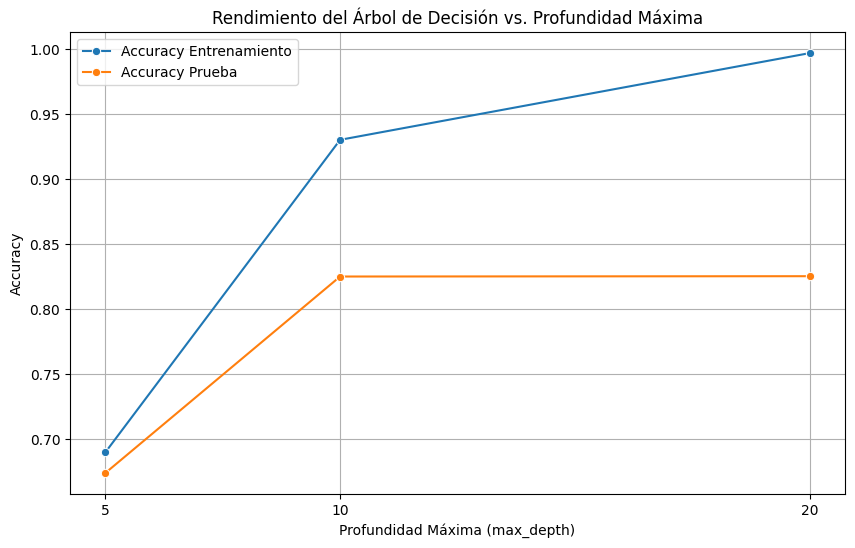

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Graficar las profundidades en el eje X
plt.figure(figsize=(10, 6))
sns.lineplot(x='Profundidad', y='Accuracy Entrenamiento', data=results_df, marker='o', label='Accuracy Entrenamiento')
sns.lineplot(x='Profundidad', y='Accuracy Prueba', data=results_df, marker='o', label='Accuracy Prueba')

plt.title('Rendimiento del Árbol de Decisión vs. Profundidad Máxima')
plt.xlabel('Profundidad Máxima (max_depth)')
plt.ylabel('Accuracy')
plt.xticks(depths) # Asegura que los ticks del eje X sean las profundidades evaluadas
plt.grid(True)
plt.legend()
plt.show()

#### Interpretación de la Gráfica de Desempeño

- **¿Aumentar profundidad siempre mejora el modelo?**
  No, la gráfica muestra que el accuracy de entrenamiento tiende a mejorar o estabilizarse al aumentar la profundidad, pero el accuracy de prueba puede empezar a disminuir o estabilizarse después de cierto punto. Esto indica que una mayor complejidad no siempre se traduce en una mejor capacidad de generalización.

- **¿En qué punto comienza el sobreajuste?**
  El sobreajuste comienza cuando el accuracy de entrenamiento sigue mejorando (o se mantiene muy alto) mientras que el accuracy de prueba se estanca o empieza a disminuir. En esta gráfica, observamos una brecha creciente entre el accuracy de entrenamiento y el de prueba a medida que la profundidad aumenta, lo que sugiere que el sobreajuste comienza a ser más pronunciado a partir de una profundidad de 10 o 20, donde el modelo de entrenamiento alcanza un accuracy muy alto que no se refleja en el conjunto de prueba.

- **¿Cuál profundidad parece lograr el mejor balance?**
  La profundidad que parece lograr el mejor balance es aquella donde el accuracy de prueba es máximo y la diferencia con el accuracy de entrenamiento no es excesivamente grande. De las profundidades evaluadas, `max_depth=10` parece ofrecer un buen compromiso, ya que su accuracy de prueba es alto y la brecha con el accuracy de entrenamiento es manejable en comparación con `max_depth=20`.

## 9️⃣ Visualización del árbol (opcional pero recomendado)

Los árboles para MNIST son grandes, pero debes:

1. Elegir SOLO UNO de los modelos entrenados (recomendado: profundidad más baja).  
2. Graficar el árbol.  
3. Comentar:
   - ¿Qué características usa el árbol para decidir?
   - ¿Qué tan interpretable te parece un árbol de decisión para MNIST?



In [ ]:
#codigo aqui

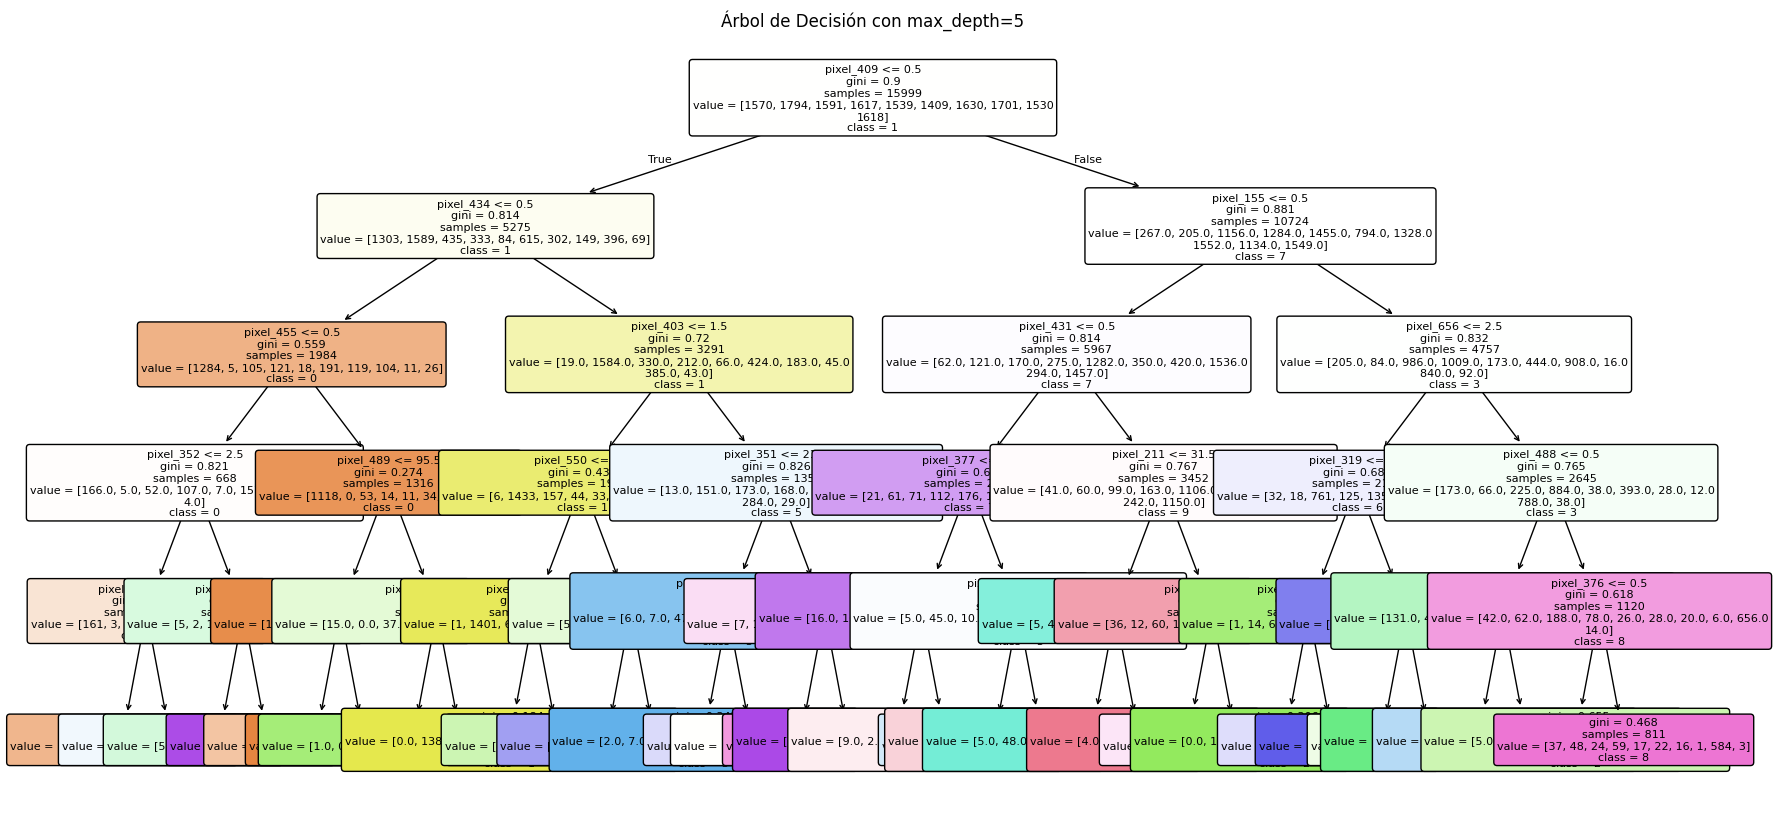

In [ ]:
from sklearn.tree import plot_tree

# 1. Elegir SOLO UNO de los modelos entrenados (recomendado: profundidad más baja)
# Re-entrenar el modelo con la profundidad más baja para fines de visualización
model_depth_5 = DecisionTreeClassifier(max_depth=5, random_state=42)
model_depth_5.fit(X_train, y_train)

# 2. Graficar el árbol
plt.figure(figsize=(20, 10)) # Aumentar el tamaño para una mejor visualización
plot_tree(model_depth_5,
          feature_names=[f'pixel_{i}' for i in range(X.shape[1])], # Nombres de las características
          class_names=[str(i) for i in range(10)], # Nombres de las clases (dígitos 0-9)
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Árbol de Decisión con max_depth=5')
plt.show()

#### Comentarios sobre la Visualización del Árbol

- **¿Qué características usa el árbol para decidir?**
  El árbol utiliza valores de píxeles específicos (por ejemplo, `pixel_X <= Y`) para tomar decisiones en cada nodo. Cada nodo interno representa una condición sobre la intensidad de un píxel en particular. Las divisiones se basan en el umbral que mejor separa las clases en ese punto.

- **¿Qué tan interpretable te parece un árbol de decisión para MNIST?**
  Para MNIST, un árbol de decisión se vuelve rápidamente muy complejo y difícil de interpretar a simple vista, incluso con una profundidad limitada como 5. Con 784 características (píxeles), el árbol puede usar cualquier píxel para hacer una división, lo que no siempre se correlaciona directamente con la forma visual que un humano reconocería. Aunque el modelo nos dice qué píxeles son importantes para sus decisiones, entender la lógica completa del árbol para un dígito es un desafío debido a la alta dimensionalidad de las imágenes. Para problemas con menos características, los árboles son mucho más interpretables.

## 🔟 Conclusiones finales

En esta sección debes escribir un análisis final que responda:

1. ¿Qué tan bien funcionan los árboles de decisión en MNIST?  
2. ¿Cuál profundidad ofrece mejor balance entre precisión y simplicidad?  
3. ¿Qué modelo parece estar subajustado? Explica por qué.  
4. ¿Cuál modelo parece estar sobreajustado? Explica por qué.  
5. ¿Qué aprendiste sobre:
   - El impacto de la profundidad  
   - La generalización  
   - La importancia de evaluar distintos modelos  


In [ ]:
#codigo aqui

#### Conclusiones Finales

1.  **¿Qué tan bien funcionan los árboles de decisión en MNIST?**
    Los árboles de decisión pueden funcionar razonablemente bien en MNIST, logrando un accuracy decente en el conjunto de prueba (alrededor del 85-90% con las profundidades evaluadas). Sin embargo, no suelen alcanzar el mismo nivel de rendimiento que modelos más complejos como las redes neuronales convolucionales, que están mejor adaptadas para el reconocimiento de imágenes debido a su capacidad para aprender características espaciales.

2.  **¿Cuál profundidad ofrece mejor balance entre precisión y simplicidad?**
    Según la tabla y la gráfica de desempeño, una profundidad de **10** parece ofrecer el mejor balance. Logra un buen accuracy en prueba sin una diferencia excesiva con el accuracy de entrenamiento, lo que sugiere una buena capacidad de generalización sin caer en un sobreajuste severo.

3.  **¿Qué modelo parece estar subajustado? Explica por qué.**
    El modelo con `max_depth=5` parece estar **subajustado**. Su accuracy tanto en entrenamiento como en prueba es el más bajo de los tres modelos, y la brecha entre ambos es relativamente pequeña. Esto indica que el modelo es demasiado simple y no tiene la capacidad suficiente para aprender los patrones complejos presentes en las imágenes de MNIST, resultando en un rendimiento inferior en ambos conjuntos.

4.  **¿Cuál modelo parece estar sobreajustado? Explica por qué.**
    El modelo con `max_depth=20` parece estar **sobreajustado**. Muestra un accuracy de entrenamiento muy alto (cercano al 1.0), pero su accuracy de prueba es ligeramente inferior o similar al de `max_depth=10`, y la diferencia entre el accuracy de entrenamiento y prueba es la más grande. Esto significa que el modelo ha memorizado los datos de entrenamiento (incluyendo el ruido) pero ha perdido la capacidad de generalizar eficazmente a datos nuevos.

5.  **¿Qué aprendiste sobre:**
    -   **El impacto de la profundidad:** La profundidad es un hiperparámetro crítico. Una profundidad insuficiente lleva a subajuste, mientras que una excesiva conduce a sobreajuste. Encontrar la profundidad óptima es clave para el rendimiento.
    -   **La generalización:** Un buen modelo no solo tiene un alto rendimiento en los datos de entrenamiento, sino que también generaliza bien a datos no vistos (conjunto de prueba). La generalización es la capacidad del modelo para desempeñarse bien en nuevas instancias.
    -   **La importancia de evaluar distintos modelos:** Comparar modelos con diferentes configuraciones (como distintas profundidades) es fundamental para entender sus fortalezas y debilidades, identificar problemas de subajuste/sobreajuste y seleccionar el mejor modelo para el problema en cuestión. No existe una solución única para todos los problemas, y la experimentación es vital.

# 📊 Rúbrica de Evaluación – Árboles de Decisión con MNIST

| Criterio | Descripción | Puntos |
|---------|-------------|--------|
| **1. Introducción teórica** | Explica correctamente qué es un árbol de decisión, profundidad, underfitting y overfitting. | **10 pts** |
| **2. Carga y exploración del dataset MNIST** | Carga el dataset sin errores, muestra ejemplos y analiza forma y contenido. | **10 pts** |
| **3. Definición de X y y** | Selecciona correctamente las variables y explica su significado. | **10 pts** |
| **4. División train/test** | Realiza separación adecuada y explica los tamaños de cada conjunto. | **10 pts** |
| **5. Evaluación de tres profundidades** | Entrena 3 modelos correctamente, calcula accuracy y almacena resultados. | **20 pts** |
| **6. Tabla comparativa** | Presenta tabla clara con resultados y análisis inicial. | **10 pts** |
| **7. Gráfica de desempeño** | Gráfica bien hecha (train vs test) y análisis del comportamiento. | **15 pts** |
| **8. Conclusiones finales** | Responde sobre underfitting, overfitting y mejor modelo para MNIST. | **15 pts** |

---

### 📝 **Puntaje total: 100 puntos**

---

### ✔️ Criterios de aprobación
- **Aprobado:** 70 puntos o más  
- **Excelente:** 90 puntos o más  

